In [2]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [3]:
from scipy.optimize import curve_fit

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
header = "D:/K_sunada/database/"
cw ="/2023-06-08/2023-06-08T165950_71ea3253-cw_sparameter/"
dd = datadict_from_hdf5(header + cw +"/data")

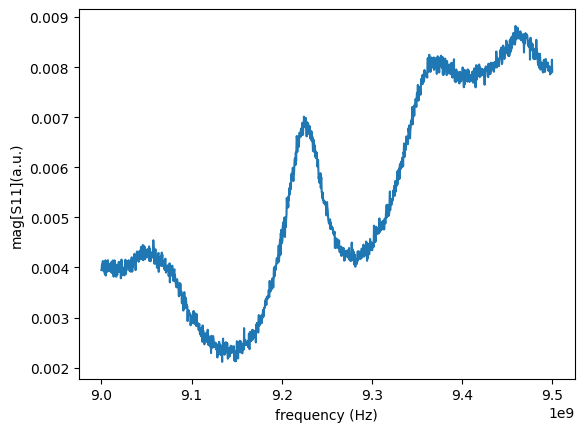

In [6]:
S11 = dd['s21']['values']
mag = np.abs(S11)
Re_S11 = S11.real
Im_S11 = S11.imag
freq = dd['frequency']['values']


plt.plot(freq, mag)
plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")
#plt.plot(freq, Im_S11)
plt.show()

In [7]:
def S11_twomode(freq, ff, fr, ke, ki, gamma, g, a0, a1, Poff,ed):
    numer = 1j*(freq-fr)+(ke-ki)/2 + (g**2)/(1j*(freq-ff)-gamma/2)
    denom = 1j*(freq-fr)-(ke+ki)/2 + (g**2)/(1j*(freq-ff)-gamma/2)
#    model = a + numer/denom
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*freq))).conj()
    return np.abs(model)

In [8]:
par_ini = {
    'ff': 9.14e9,
    'fr':9.29e9,
    'ke':0.8e9,
    'ki':0,
    'gamma':0,
    'g':0,
#    'a' :0
    'a0':0,
    'a1':0,
    'Poff':0,
    'ed':0   
}

par_min = {
    'ff': 0,
    'fr':0,
    'ke':0,
    'ki':0,
    'gamma':0,
    'g':0,
#    'a':0
    'a0':-np.inf,
    'a1':-np.inf,
    'Poff':-np.inf,
    'ed':-np.inf
}

par_max = {
    'ff': np.inf,
    'fr':np.inf,
    'ke':np.inf,
    'ki':np.inf,
    'gamma':np.inf,
    'g':np.inf,
#    'a':np.inf
    'a0':np.inf,
    'a1':np.inf,
    'Poff':np.inf,
    'ed':np.inf 
}

par_vary = {
    'ff': True,
    'fr':True,
    'ke':True,
    'ki':True,
    'gamma':True,
    'g':True,
#    'a':True
    'a0':True,
    'a1':True,
    'Poff':True,
    'ed':True 
}

In [9]:
model = lmfit.Model(S11_twomode)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [10]:
result = model.fit(data = mag, params =params, freq = freq)

C:\Users\qipe\AppData\Local\Temp\ipykernel_23132\1836521215.py:2: RuntimeWarning: invalid value encountered in divide
  numer = 1j*(freq-fr)+(ke-ki)/2 + (g**2)/(1j*(freq-ff)-gamma/2)
C:\Users\qipe\AppData\Local\Temp\ipykernel_23132\1836521215.py:3: RuntimeWarning: invalid value encountered in divide
  denom = 1j*(freq-fr)-(ke+ki)/2 + (g**2)/(1j*(freq-ff)-gamma/2)
C:\Users\qipe\AppData\Local\Temp\ipykernel_23132\1836521215.py:5: RuntimeWarning: invalid value encountered in divide
  model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*freq))).conj()


ValueError: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.

In [ ]:
def resonator_fit_from_dir(dirname,fit=True):
    header = "D:/K_sunada/database/"
    dd = datadict_from_hdf5(header+dirname+"/data")
    s11 = dd['s21']['values']
    f = dd['frequency']['values'] * 1e-9
    if fit:
        result = Model_fit(f,s11)
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
        ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
        ax[0].legend()
        ax[1].plot(f, np.angle(s11), '.', color='k')
        ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
        ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
        ax[1].legend()

        return result
    else:
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].plot(f, np.abs(s11), '.', color='k')
        ax[1].plot(f, np.angle(s11), '.', color='k')
        return f, s11, fig, ax

In [ ]:
def fit_partial(ff,fs11,startf,stopf):
    id1,id2 = np.argmin(np.abs(ff-startf)),np.argmin(np.abs(ff-stopf))
    f = ff[id1:id2]
    s11 = fs11[id1:id2]
    result = Model_fit(f,s11)
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    ax[0].plot(f, np.abs(s11), '.', color='k')
    ax[0].plot(f, np.abs(result.init_fit), '--', label='initial fit', color='orange')
    ax[0].plot(f, np.abs(result.best_fit), '-', label='best fit', color='red')
    ax[0].legend()
    ax[1].plot(f, np.angle(s11), '.', color='k')
    ax[1].plot(f, np.angle(result.init_fit), '--', label='initial fit', color='orange')
    ax[1].plot(f, np.angle(result.best_fit), '-', label='best fit', color='red')
    ax[1].legend()

    return result

## DPR1-l-120-44

In [ ]:
dirlist = os.listdir('./database/2023-06-08/')
dirlist


['2023-06-08T155400_3f30a899-cw_sparameter',
 '2023-06-08T155942_0b5c38bf-cw_sparameter',
 '2023-06-08T160048_326d848c-cw_sparameter',
 '2023-06-08T160129_4b41a975-cw_sparameter',
 '2023-06-08T160454_c558f3f5-cw_sparameter',
 '2023-06-08T161130_b1698fd3-cw_sparameter',
 '2023-06-08T161229_d4397624-cw_sparameter',
 '2023-06-08T161431_1cd446b9-cw_sparameter',
 '2023-06-08T161858_bc803753-cw_sparameter',
 '2023-06-08T162255_4942dd82-cw_sparameter',
 '2023-06-08T162412_77269f82-cw_sparameter',
 '2023-06-08T163210_942c5972-cw_sparameter',
 '2023-06-08T164814_d2f2b025-cw_sparameter',
 '2023-06-08T164947_0a851479-cw_sparameter',
 '2023-06-08T165154_563c543e-cw_sparameter',
 '2023-06-08T165554_e4ffc8c6-cw_sparameter',
 '2023-06-08T165709_11c12b76-cw_sparameter',
 '2023-06-08T165839_4729cf13-cw_sparameter',
 '2023-06-08T165950_71ea3253-cw_sparameter']

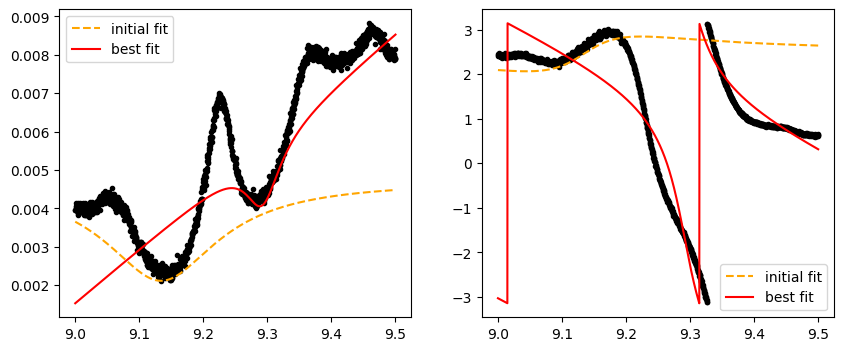

In [ ]:
result0 = resonator_fit_from_dir('2023-06-08/'+dirlist[-1])
result0

In [ ]:
fc = result0.params['fc'].value
ke = result0.params['ke'].value
ki = result0.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 1165.909335929279, 'Qi =': 4672.224405405423}


-spacer 1.2mm

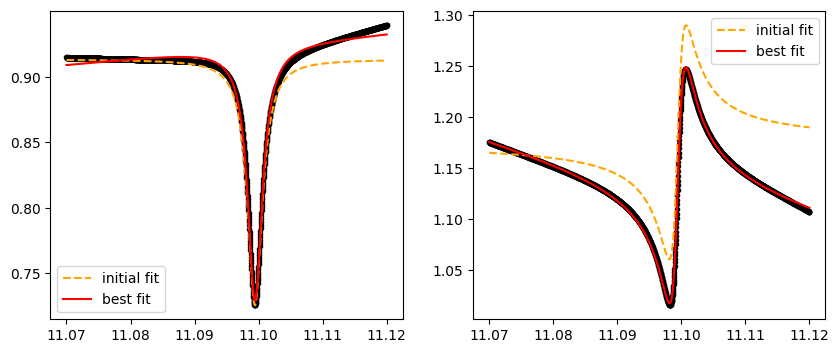

In [ ]:
result1 = resonator_fit_from_dir('2023-06-02/'+dirlist[1])
result1

In [ ]:
fc = result1.params['fc'].value
ke = result1.params['ke'].value
ki = result1.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 35797.20186243869, 'Qi =': 4212.466848433921}


-spacer 1.4mm

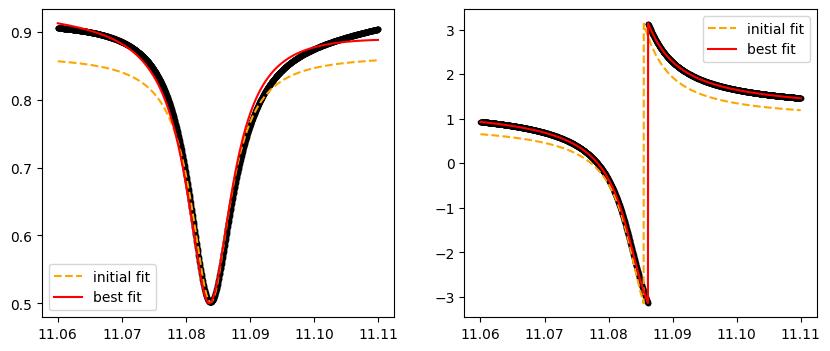

In [ ]:
result2 = resonator_fit_from_dir('2023-06-02/'+dirlist[2])
result2

In [ ]:
fc = result2.params['fc'].value
ke = result2.params['ke'].value
ki = result2.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 1434.445454165092, 'Qi =': 4904.017258930101}


-spacer 1.6mm

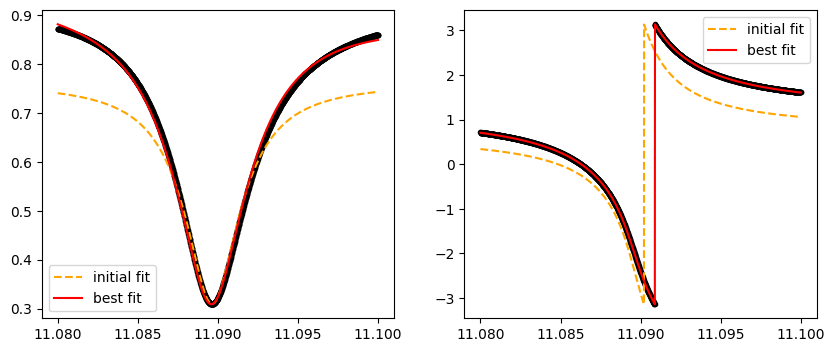

In [ ]:
result3 = resonator_fit_from_dir('2023-06-02/'+dirlist[3])
result3

In [ ]:
fc = result3.params['fc'].value
ke = result3.params['ke'].value
ki = result3.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 2309.6889702948415, 'Qi =': 4666.025254143852}


-spacer 1.8mm

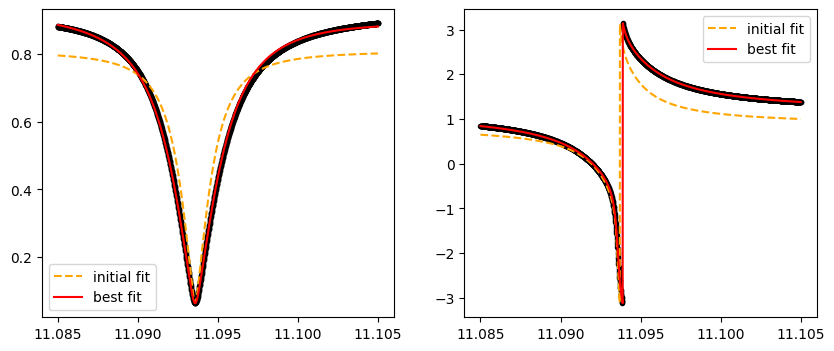

In [ ]:
result4 = resonator_fit_from_dir('2023-06-02/'+dirlist[4])
result4

In [ ]:
fc = result4.params['fc'].value
ke = result4.params['ke'].value
ki = result4.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 3922.086348742752, 'Qi =': 4508.31823971645}


-spacer 2.0mm

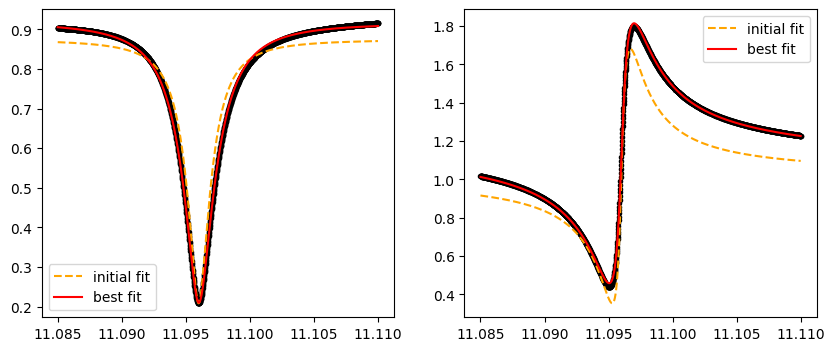

In [ ]:
result5 = resonator_fit_from_dir('2023-06-02/'+dirlist[5])
result5

In [ ]:
fc = result5.params['fc'].value
ke = result5.params['ke'].value
ki = result5.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 7045.14784700463, 'Qi =': 4427.0224598659}


-spacer 1.9mm

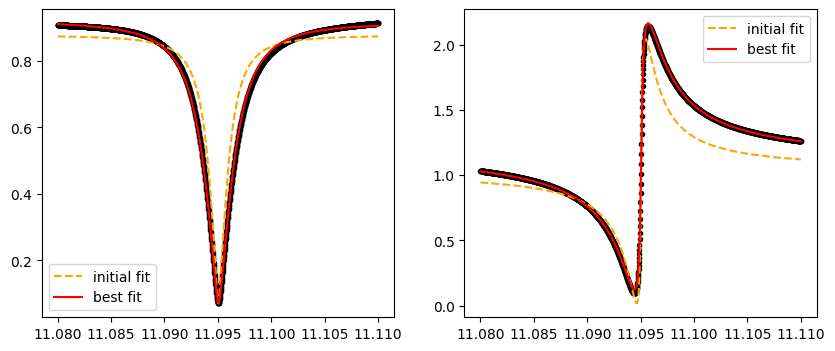

In [ ]:
result6 = resonator_fit_from_dir('2023-06-02/'+dirlist[6])
result6

In [ ]:
fc = result6.params['fc'].value
ke = result6.params['ke'].value
ki = result6.params['ki'].value

Qe = fc / ke
Qi = fc / ki
print({'Qe =':Qe,'Qi =':Qi })

{'Qe =': 5228.9058491248525, 'Qi =': 4462.787651384504}
